<a href="https://colab.research.google.com/github/LorenzoBioinfo/Evolutionary_LM_ProteinKinases/blob/main/Evolutionary_LM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 Evolutionary Language Model su Protein Chinasi

> **Cosa impara un language model addestrato su sequenze proteiche? E cosa impara dell'evoluzione di famiglie proteiche?**

L'idea di questo notebook è di addestrare da zero un modello decoder-only su una famiglia di proteine, le **chinasi**.

Le chinasi sono enzimi (fosfotransferasi) fondamentali che regolano i processi cellulari trasferendo gruppi fosfato da molecole ad alta energia (come l'ATP) a substrati specifici, in un processo chiamato **fosforilazione**. Sono essenziali per la trasduzione del segnale, il metabolismo e la divisione cellulare, e sono tra le proteine più conservate nell'evoluzione.
Nell'uomo si contano più di 500 protein chinasi. Molte sono target di farmaci antitumorali — tra i più noti *imatinib* e *gefitinib*.

---

🔬 **La domanda centrale:** cosa può imparare sulla biologia delle chinasi un language model addestrato solo su sequenze? Il modello impara i vincoli evolutivi? Riconosce le posizioni funzionali? Generalizza alle chinasi umane senza averle mai viste?

---

Per rispondere useremo il dominio **PF00069** — il dominio che contiene l'attività chinasica.
Le chinasi contengono diversi domini evoluzionisticamente conservati. Focalizzandoci su PF00069 isoliamo il segnale che ci interessa, evitando che il modello si *distragga* su regioni non catalitiche. Un vantaggio pratico: la lunghezza del dominio è grossomodo costante tra gli organismi (250–300 aa), il che rende il training più pulito e gli esperimenti più diretti.

📂 **Il notebook è diviso in 3 sezioni:**
- **Sezione 1** — Download e preparazione dei dati
- **Sezione 2** — Architettura e training del modello
- **Sezione 3** — Esperimenti

⚗️ **Split train / validation:**
Per il training useremo sequenze di chinasi di tutti gli organismi —uomo, batteri, lieviti, invertebrati, vertebrati non-umani. Training: 90%  tutte le chinasi Swiss-Prot (umane incluse)  ~6000 sequenze
Validation: 10% random delle stesse sequenze.

Avremmo potuto fare uno split per famiglia chinasica o per specie ma per lo scopo di questo notebook, lasciamo uno split random semplice.

In [ ]:
# Installiamo le librerie necessarie e eseguiamo i corrispettivi import
!pip install biopython requests matplotlib torch umap-learn seaborn scikit-learn -q
import os
import json, math, pickle, random, time
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from pathlib import Path
from dataclasses import dataclass
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import umap
from torch.utils.data import Dataset, DataLoader
from Bio import Entrez, SeqIO
from Bio.Seq import Seq as BioSeq
from Bio.SeqRecord import SeqRecord
from scipy import stats
from scipy.spatial.distance import cosine
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')


# from google.colab import drive
# drive.mount('/content/drive')
# import os; os.chdir('/content/drive/MyDrive/dna_lm')

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)
Path('figures').mkdir(exist_ok=True)
Path('checkpoints').mkdir(exist_ok=True)


Device: cpu


## 📂 Sezione 1 — Dati: sequenze del dominio chinasico
### 1.1 Download da UniProt Swiss-Prot


In questa sezione del notebook, scarichiamo le sequenze proteiche in formato FASTA.
Usiamo il database **UniProt Swiss-Prot** . Nella query inseriamo il dominio pfam PF00069. Otterremo la sequenza della chinasi completa e le coordinate del dominio PF00069.

Quindi estrarremo dalla sequenza la regione indicata e la salveremo per in un file FASTA.

In [ ]:
# Testiamo la chiamata con un solo risultato
url = "https://rest.uniprot.org/uniprotkb/search"
params = {
    "query": "reviewed:true AND (database:pfam AND xref:pfam-PF00069)",
    "format": "json",
    "size": 1,
    "fields": "accession,organism_name,sequence,ft_domain"
}

r = requests.get(url, params=params)
print(r.status_code)
print(r.json().keys())
print(r.json()['results'][0].keys())

200
dict_keys(['results'])
dict_keys(['entryType', 'primaryAccession', 'organism', 'features', 'sequence', 'extraAttributes'])


In [ ]:
risultato = r.json()['results'][0]

# Guarda la sequenza
print('Sequenza:')
print(risultato['sequence'])

print("Organismo:")
print(risultato['organism'])

print('\nFeatures:')
for f in risultato['features']:
    print(f)

Sequenza:
{'value': 'MVTCFSPHRQGGPTPVDGTPPFTPFKRSNSGLSSMEVPRHTPSPIPQTRASTRRQGTLVRTRSSPTRVALEVSSTNNLNFSPPSPDAQPVDAKQVMAEPFKTRQLRGRGIENTPAISSPLKRREATTASEAGDFASPRVKRRSQDGINRSSRSSSPAGSSSDSSSTSSRNKASRTSLFSGPGKIISHTPKKPTSLKKVINTHHFEKPKIARSRLQPTKPPVFSVSTPLAPTRVKRITSFDDFVSPAPKEPAVPQTANAGLSRTPFAQTTSDTPFKKPFAAPFPKPTFTPMPQHSTFATPQISKPVQGHPPVFMSTGLLTKKNRPTNANGTSFLPPETPCKKPTFMTRKPIMINNAPPDTPFTHKGRGRLNFTRTESFASIVDSGSPEASQTNTQQEYLQTPTKRLHTSDSASSLRGLNKKWKNDPSLSQESAPPQTPQASVSIIDLDASRLSISGKPSQPLFAVPSTPRSARDLFGNLRQTPGNANDEEDNSPDESFNTSGIEQTMTPVMDRTSKTFSKEWDPALESKFSKVTQIGAGEFSVVFEVEERISASQPSTQLITPENSSENGSPPNPPAMMPRHYAVKRVQFHGQRDRDMRIEEVTVLKSLGKHKNVVEYIDSWETALNLRVYIQTEFCELGGLDNFLSDYGNHGRLDPFRIWKIFTEISEGLHHIHEMSFLHLDLKPSNILVGYDGTLKIADFGMATKYPASRSLEREGDREYLAPEVLQKHQYDRPADIFSLGLTLLEIAANVQLPDNGPSWQKLRAGDLGEIPDLTPESLMHSCIRDDRGFPVVISDDSIGEIGAESFEPESSFVVSPASHLEGMLAKFTNNPHFRARQTQDLIDAPKFLEGDSLKYMINWLISPDPGLRPSTSEILASSEVRWIKGHRRCSALVYEGEWGPAEPLSDFCEDMDISDMSGDIKLDVDGEDWIMME', 'length': 935, 'molWeight': 103165, 'crc6

UniProt ha un limite di 500 sequenze alla volta quindi dobbiamo eseguire un loop per scaricarle tutte. Usiamo next per andare alla pagina successiva.
Per ogni sequenza estraiamo i domini chinasici, se ce ne sono più di uno, li prendiamo entrambi. Prendiamo solo le sequenze che hanno una lunghezza compresa tra i 200-400 aa.

In [ ]:
url_base = "https://rest.uniprot.org/uniprotkb/search"
params = {
    "query": "(database:pfam AND xref:pfam-PF00069)  AND existence:1", #reviewed:true AND
    "format": "json",
    "size": 500,
    "fields": "accession,organism_name,sequence,ft_domain"
}

r = requests.get(url_base, params=params)


In [ ]:

## Funzione per estrare la pagina next
def estrai_next_url(headers):
    """
    Estrae l'URL della pagina successiva dall'header Link.
    Restituisce None se non c'è pagina successiva.
    """
    link = headers.get('Link', '')
    if 'rel="next"' not in link:
        return None

    url = link.split('<')[1].split('>')[0]
    return url


In [ ]:
risultato["features"]

[{'type': 'Domain',
  'location': {'start': {'value': 529, 'modifier': 'EXACT'},
   'end': {'value': 885, 'modifier': 'EXACT'}},
  'description': 'Protein kinase',
  'evidences': [{'evidenceCode': 'ECO:0000255',
    'source': 'PROSITE-ProRule',
    'id': 'PRU00159'}]}]

In [ ]:
r = requests.get(url_base, params=params)
count = 0
if os.path.exists('PF00069.fasta'):
    os.remove('PF00069.fasta')

with open("PF00069.fasta", "w") as fasta:
    while True:

      risultati = r.json()['results']

      for risultato in risultati:


        sequenza = risultato['sequence']["value"]
        organismo=risultato['organism']['scientificName']
        accession=risultato['primaryAccession']

        domini_chinasi = [
            f for f in risultato.get('features', [])
            if f.get('type') == 'Domain'
            and 'kinase' in f.get('description', '').lower()
        ]

        if not domini_chinasi:
            continue

        for i, dominio in enumerate(domini_chinasi):

          count=count+1
          if count%100==0:
            print(count)


          start=dominio["location"]["start"]["value"]
          end=dominio["location"]["end"]["value"]

          dominio_seq=sequenza[start-1:end]
          suffix = f'_domain{i+1}' if len(domini_chinasi) > 1 else ''





          fasta.write(f"> {accession}{suffix}| {organismo} |{start}-{end} |{len(dominio_seq)}\n")
          fasta.write(dominio_seq)
          fasta.write("\n")

      url = estrai_next_url(r.headers)

      if url is None:
            break
      time.sleep(0.10)
      r = requests.get(url)


print(f'Sequenze scaricate: {count}')


100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
Sequenze scaricate: 7879


In [ ]:
## filtriamo le sequenze

from Bio import SeqIO

sequenze_filtrate = []
scartate = 0

for record in SeqIO.parse('PF00069.fasta', 'fasta'):
    seq = str(record.seq)
    if len(seq) < 200 or len(seq) > 400:
        scartate += 1
        continue
    sequenze_filtrate.append(record)

SeqIO.write(sequenze_filtrate, 'PF00069_filtered.fasta', 'fasta')

print(f'Sequenze tenute:  {len(sequenze_filtrate)}')
print(f'Sequenze scartate: {scartate}')




Sequenze tenute:  6333
Sequenze scartate: 1546


### Riepilogo
Abbiamo completato il download dei dati. Abbiamo scaricato le sequenze da Uniprot estrando l'informazione dei domini pfam. Abbiamo poi filtrato le sequenze in moodo da tenere solo quelle con una lunghezza tra 200-400 aa.
Il file finale è un file FASTA con queste informazioni per ogni sequenza:
accession, organismo, coordinate del dominio, lunghezza.

Recap dei numeri:
- Sequenze scaricate: 7879
- Sequenze tenute:  6333
- Sequenze scartate: 1546


Guardiamo ora che dati abbiamo scaricato con qualche visualizzazione

## Esplorazione dei dati

Guardiamo ora in faccia i dati che abbiamo scaricato. Vogliamo fare queste visualizzazioni:

* Grafico 1 — distribuzione delle lunghezze:
Istogramma delle lunghezze delle sequenze filtrate. Il dominio PF00069 ha una lunghezza conservata, quindi ci aspettiamo un picco tra i 250-300 aa di lunghezza.


* Grafico 2 — top 15 organismi:
Barchart orizzontale con i 15 organismi più rappresentati nel dataset. Per questo notebook, vogliamo un dataset diversificato perché vogliamo che il modello riesca a generalizzare bene, imparando vincoli evolutivi generali.

In [ ]:
from Bio import SeqIO
from collections import Counter
import matplotlib.pyplot as plt


lunghezze = []
organismi = []

for record in SeqIO.parse('PF00069_filtered.fasta', 'fasta'):
    lunghezze.append(len(record.seq))
    organismi.append(record.description.split('|')[1])
    pass


print(f'Sequenze totali: {len(lunghezze)}')
print(f'Lunghezza media: {sum(lunghezze)/len(lunghezze):.1f} aa')
print(f'Lunghezza min:   {min(lunghezze)} aa')
print(f'Lunghezza max:   {max(lunghezze)} aa')
print(f'Organismi unici: {len(set(organismi))}')
print(f'\nTop 10 organismi:')
for org, count in Counter(organismi).most_common(10):
    print(f'  {org}: {count}')



Sequenze totali: 6333
Lunghezza media: 271.7 aa
Lunghezza min:   200 aa
Lunghezza max:   400 aa
Organismi unici: 155

Top 10 organismi:
   Homo sapiens : 879
   Zea mays : 824
   Mus musculus : 696
   Rattus norvegicus : 635
   Arabidopsis thaliana : 574
   Danio rerio : 472
   Gallus gallus : 350
   Sus scrofa : 334
   Oryza sativa subsp. japonica : 269
   Drosophila melanogaster : 239


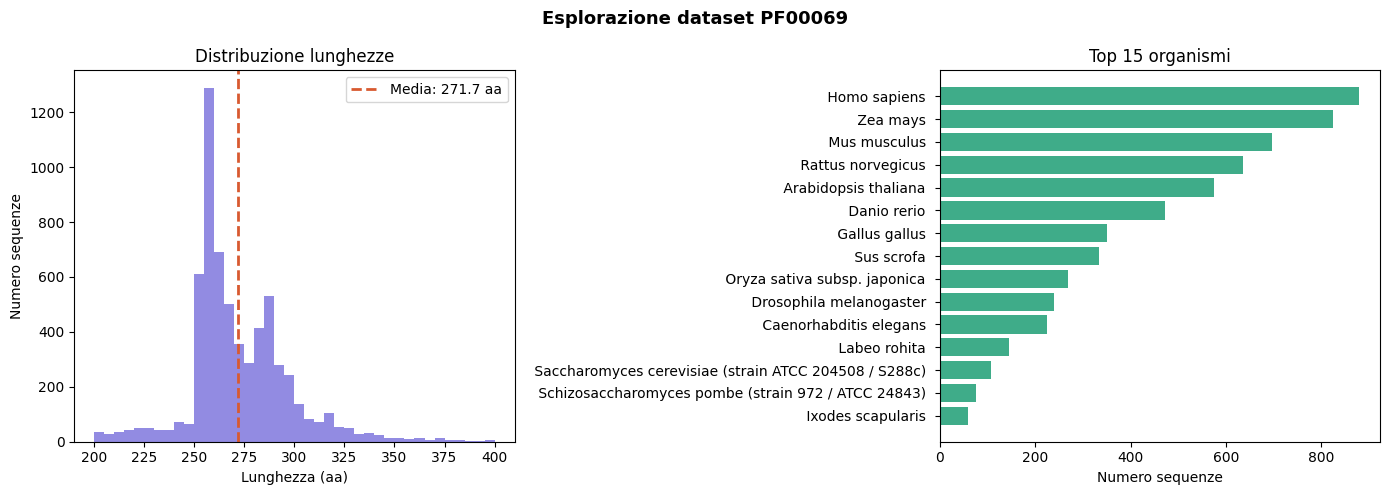

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Esplorazione dataset PF00069', fontsize=13, fontweight='bold')

# Grafico 1 — distribuzione lunghezze
axes[0].hist(lunghezze, bins=40, color='#7F77DD', edgecolor='none', alpha=0.85)
axes[0].axvline(sum(lunghezze)/len(lunghezze),
                color='#D85A30', linestyle='--', linewidth=2,
                label=f'Media: {sum(lunghezze)/len(lunghezze):.1f} aa')
axes[0].set_xlabel('Lunghezza (aa)')
axes[0].set_ylabel('Numero sequenze')
axes[0].set_title('Distribuzione lunghezze')
axes[0].legend()

# Grafico 2 — top 15 organismi
top15 = Counter(organismi).most_common(15)
nomi  = [x[0] for x in top15][::-1]
conti = [x[1] for x in top15][::-1]

axes[1].barh(nomi, conti, color='#1D9E75', edgecolor='none', alpha=0.85)
axes[1].set_xlabel('Numero sequenze')
axes[1].set_title('Top 15 organismi')

plt.tight_layout()
plt.savefig('figures/esplorazione_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

### Riepilogo della Data Exploration
Abbiamo esplorato la distribuzione dei dati.
Dal grafico della distribuzione delle lunghezze, vediamo che ci sono due picch, uno intorno a 250 e uno a 300: potrebbero riflettere i due sottogruppi di chinasi con lunghezze diverse. La media della distribuzione è a 275,come atteso.
Abbiamo 155 oranismi totali, l'uomo è al primo posto per rappresentanza, con più di 800 sequenze, seguito da Zea mays e topo.

## 🤖 Sezione 2 — Tokenizer Architettura e training



Per questo notebook costruiremo un modello Transformer decoder-only stile GPT.
Il modello sarà allenato nel task di next token prediction: dovrà predire
con accuratezza l'aminoacido successivo data una stringa di aminoacidi in input.

**Vocabolario:** 20 token — uno per ogni aminoacido standard — più 4 token
speciali (PAD, BOS, EOS, UNK), per un totale di 24 token.

**Come funziona il modello:**

- **Token Embedding** — ogni aminoacido viene convertito in un vettore
  di 128 numeri, un "punto" in uno spazio ad alta dimensione.
- **Positional Encoding** — aggiunge informazione sulla posizione
  del token nella sequenza.
- **CausalSelfAttention** — ogni token può guardare indietro a tutti
  quelli precedenti e pesare quanto ciascuno è rilevante per la predizione
  successiva. Causale significa che non può vedere il futuro.
- **FeedForward** — una piccola rete neurale applicata indipendentemente
  a ogni posizione.
- **6 × TransformerBlock** — ripetiamo attenzione + feedforward 6 volte.
  I layer bassi catturano pattern locali (es. dipeptidi frequenti,
  composizione aminoacidica), quelli profondi strutture più astratte
  (es. motivi funzionali conservati, famiglie di chinasi).
- **LM Head** — riconverte le rappresentazioni in probabilità sul vocabolario.
  Il training ottimizza la probabilità dell'aminoacido corretto al passo successivo.

In [ ]:
## Iniziamo al tokenizer

class AminoAcidTokenizer:

    AMINOACIDI = list('ACDEFGHIKLMNPQRSTVWY')  # 20 aminoacidi standard
    SPECIAL_TOKENS = {'<PAD>': 0, '<UNK>': 1, '<BOS>': 2, '<EOS>': 3}

    def __init__(self):
        self.vocab = dict(self.SPECIAL_TOKENS)
        self._build_vocab()
        pass

    def _build_vocab(self):
        for i, aa in enumerate(self.AMINOACIDI):
          self.vocab[aa] = i + len(self.SPECIAL_TOKENS)
        self.inv_vocab = {v: k for k, v in self.vocab.items()}

    @property
    def vocab_size(self):
        return len(self.vocab)


    def encode(self, seq: str) -> list[int]:
        seq = seq.upper()
        tokens = [self.SPECIAL_TOKENS['<BOS>']]
        for i in range(len(seq)):
            kmer = seq[i]
            tokens.append(self.vocab.get(kmer, self.SPECIAL_TOKENS['<UNK>']))
        tokens.append(self.SPECIAL_TOKENS['<EOS>'])

        return tokens

    def decode(self, ids: list[int]) -> str:
        kmers = [self.inv_vocab.get(i, '?') for i in ids
                 if i not in self.SPECIAL_TOKENS.values()]
        return ''.join(kmers)

In [ ]:
tokenizer = AminoAcidTokenizer()

# Test base
print(f'Vocab size: {tokenizer.vocab_size}')  # atteso: 24
print(f'Vocabolario: {tokenizer.vocab}')

# Test encode/decode
seq_test = 'MGKL'
encoded = tokenizer.encode(seq_test)
decoded = tokenizer.decode(encoded)
print(f'\nSequenza originale: {seq_test}')
print(f'Encoded: {encoded}')
print(f'Decoded: {decoded}')
print(f'Round-trip corretto: {seq_test == decoded}')

# Test con carattere sconosciuto
seq_unk = 'MGXKL'  # X non è un aminoacido standard
encoded_unk = tokenizer.encode(seq_unk)
print(f'\nTest UNK: {encoded_unk}')
print(f'ID di UNK: {tokenizer.SPECIAL_TOKENS["<UNK>"]}')

Vocab size: 24
Vocabolario: {'<PAD>': 0, '<UNK>': 1, '<BOS>': 2, '<EOS>': 3, 'A': 4, 'C': 5, 'D': 6, 'E': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'K': 12, 'L': 13, 'M': 14, 'N': 15, 'P': 16, 'Q': 17, 'R': 18, 'S': 19, 'T': 20, 'V': 21, 'W': 22, 'Y': 23}

Sequenza originale: MGKL
Encoded: [2, 14, 9, 12, 13, 3]
Decoded: MGKL
Round-trip corretto: True

Test UNK: [2, 14, 9, 1, 12, 13, 3]
ID di UNK: 1


In [ ]:
## Creaimo il ProteinDataset

class ProteinDataset(Dataset):
    """
    Dataset per next-token prediction su sequenze genomiche.

    Divide il genoma in finestre di lunghezza fissa con stride.
    Input: token[0..ctx-1], Target: token[1..ctx]
    """

    def __init__(
        self,
        sequences: list[str],
        tokenizer: AminoAcidTokenizer,
        context_len: int = 402
    ):
        self.tokenizer   = tokenizer
        self.context_len = context_len
        self.chunks      = []

        for seq in sequences:
            tokens = tokenizer.encode(seq)
            if len(tokens) < context_len + 1:
            # padda con PAD fino a context_len + 1
              tokens = tokens + [tokenizer.SPECIAL_TOKENS['<PAD>']] * (context_len + 1 - len(tokens))
            else:
                # tronca se più lunga
                tokens = tokens[:context_len + 1]
            self.chunks.append(tokens)

    def __len__(self) -> int:
        return len(self.chunks)

    def __getitem__(self, idx: int):
        chunk  = torch.tensor(self.chunks[idx], dtype=torch.long)
        x = chunk[:-1]   # input
        y = chunk[1:]    # target da predire
        return x, y


# Test rapido
seqs_test = ['MGKLIVT', 'ACDEFGHIKLM']
ds_test   = ProteinDataset(seqs_test, tokenizer, context_len=10)
print(f'Esempi nel dataset: {len(ds_test)}')
x, y = ds_test[0]
print(f'Shape x: {x.shape}')  # atteso: torch.Size([10])
print(f'Shape y: {y.shape}')  # atteso: torch.Size([10])
print(f'x: {x}')
print(f'y: {y}')


Esempi nel dataset: 2
Shape x: torch.Size([10])
Shape y: torch.Size([10])
x: tensor([ 2, 14,  9, 12, 13, 11, 21, 20,  3,  0])
y: tensor([14,  9, 12, 13, 11, 21, 20,  3,  0,  0])


Possiamo ora dividere il nostro dataset in train e test.

In [ ]:
sequences = []
for record in SeqIO.parse('PF00069_filtered.fasta', 'fasta'):
    sequences.append(str(record.seq))

print(f'Sequenze caricate: {len(sequences)}')

dataset = ProteinDataset(sequences, tokenizer, context_len=402)
print(f'Esempi nel dataset: {len(dataset)}')

# Split 90/10
from torch.utils.data import random_split
train_size = int(0.9 * len(dataset))
val_size   = len(dataset) - train_size
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=generator
)

print(f'Train: {len(train_dataset)}')
print(f'Val:   {len(val_dataset)}')

Sequenze caricate: 6333
Esempi nel dataset: 6333
Train: 5699
Val:   634


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f'Batch per epoch (train): {len(train_loader)}')
print(f'Batch per epoch (val):   {len(val_loader)}')

Batch per epoch (train): 179
Batch per epoch (val):   20


In [ ]:
@dataclass
class ProteinLMConfig:
    vocab_size:  int   = 24     # 20 aminoacidi + 4 speciali
    context_len: int   = 402    # lunghezza massima sequenza
    n_embed:     int   = 128
    n_heads:     int   = 8
    n_layers:    int   = 6
    dropout:     float = 0.1


class StandardPositionalEncoding(nn.Module):
    """Positional encoding sinusoidale"""

    def __init__(self, config):
        super().__init__()
        pe  = torch.zeros(config.context_len, config.n_embed)
        pos = torch.arange(config.context_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, config.n_embed, 2).float()
            * (-math.log(10000.0) / config.n_embed)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]



class CausalSelfAttention(nn.Module):
    """Multi-head self-attention causale. Ogni token vede solo i token precedenti."""

    def __init__(self, config):
        super().__init__()
        assert config.n_embed % config.n_heads == 0
        self.n_heads  = config.n_heads
        self.n_embed  = config.n_embed
        self.head_dim = config.n_embed // config.n_heads
        self.qkv_proj = nn.Linear(config.n_embed, 3 * config.n_embed, bias=False)
        self.out_proj = nn.Linear(config.n_embed, config.n_embed, bias=False)
        self.dropout  = nn.Dropout(config.dropout)
        self.register_buffer(
            'mask',
            torch.tril(torch.ones(config.context_len, config.context_len))
            .unsqueeze(0).unsqueeze(0)
        )

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv_proj(x).split(self.n_embed, dim=2)

        def reshape(t):
            return t.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        q, k, v = reshape(q), reshape(k), reshape(v)
        scale   = self.head_dim ** -0.5
        scores  = (q @ k.transpose(-2, -1)) * scale
        scores  = scores.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))
        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)
        out     = (weights @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out), weights.detach()


class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embed, 4 * config.n_embed),
            nn.GELU(),
            nn.Linear(4 * config.n_embed, config.n_embed),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1  = nn.LayerNorm(config.n_embed)
        self.attn = CausalSelfAttention(config)
        self.ln2  = nn.LayerNorm(config.n_embed)
        self.ff   = FeedForward(config)

    def forward(self, x):
        attn_out, weights = self.attn(self.ln1(x))
        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return x, weights


class ProteinLM(nn.Module):
    """
    Protein Language Model — transformer decoder-only.
    Embedding → PosEnc → N x Block → LayerNorm → LM Head
    """

    def __init__(self, config):
        super().__init__()
        self.config      = config
        self.token_embed = nn.Embedding(config.vocab_size, config.n_embed)
        self.pos_enc  =   StandardPositionalEncoding(config)

        self.dropout  = nn.Dropout(config.dropout)
        self.blocks   = nn.ModuleList([TransformerBlock(config) for _ in range(config.n_layers)])
        self.ln_final = nn.LayerNorm(config.n_embed)
        self.lm_head  = nn.Linear(config.n_embed, config.vocab_size, bias=False)
        self.lm_head.weight = self.token_embed.weight
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0.0, 0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, 0.0, 0.02)

    def forward(self, idx, targets=None):
        x = self.dropout(self.pos_enc(self.token_embed(idx)))
        all_attn = []
        for block in self.blocks:
            x, w = block(x)
            all_attn.append(w)
        logits = self.lm_head(self.ln_final(x))
        loss   = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, self.config.vocab_size),
                targets.view(-1),
                ignore_index=0
            )
        return logits, loss, all_attn

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=100, temperature=1.0, top_k=None):
        self.eval()
        for _ in range(max_new_tokens):
            idx_ctx = idx[:, -self.config.context_len:]
            logits, _, _ = self(idx_ctx)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, [-1]]] = float('-inf')
            idx = torch.cat([idx, torch.multinomial(F.softmax(logits, dim=-1), 1)], dim=1)
        return idx

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)






In [ ]:
config = ProteinLMConfig()
model  = ProteinLM(config).to(device)

print(f'Parametri totali: {model.count_parameters():,}')

# Test forward pass
dummy_x = torch.randint(0, config.vocab_size, (2, config.context_len)).to(device)
dummy_y = torch.randint(0, config.vocab_size, (2, config.context_len)).to(device)

logits, loss, attn = model(dummy_x, dummy_y)

print(f'Output logits: {logits.shape}')   # atteso: (2, 402, 24)
print(f'Loss iniziale: {loss.item():.4f}') # atteso: ~ln(24) = {math.log(24):.4f}
print(f'Layer attenzione: {len(attn)}')    # atteso: 6

Parametri totali: 1,189,888
Output logits: torch.Size([2, 402, 24])
Loss iniziale: 3.2034
Layer attenzione: 6


In [ ]:
BATCH_SIZE   = 32
MAX_EPOCHS   = 40
LR           = 3e-4
WARMUP_STEPS = 200
GRAD_CLIP    = 1.0
EVAL_EVERY   = 100
SAVE_EVERY   = 500
total_steps = MAX_EPOCHS * len(train_loader)


def get_lr(step, warmup, total, max_lr):
    if step < warmup:
        return max_lr * step / warmup
    progress = (step - warmup) / max(1, total - warmup)
    return max_lr * 0.5 * (1 + math.cos(math.pi * progress))


@torch.no_grad()
def evaluate(model, loader, max_batches=50):
    model.eval()
    losses = []
    for i, (x, y) in enumerate(loader):
        if i >= max_batches:
            break
        _, loss, _ = model(x.to(device), y.to(device))
        losses.append(loss.item())
    model.train()
    return float(np.mean(losses))


def train_model(config, name):
    """
    Salva checkpoint in checkpoints/{name}/
    Restituisce l'history con train/val loss e lr.
    """
    print(f'\n{"="*50}')
    print(f'Training: {name}')
    print(f'{"="*50}')

    ckpt_dir = Path(f'checkpoints/{name}')
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    model     = ProteinLM(config).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    history   = {'step': [], 'train_loss': [], 'val_loss': [], 'lr': []}
    best_val  = float('inf')
    step      = 0

    model.train()
    for epoch in range(MAX_EPOCHS):
        t0 = time.time()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            lr = get_lr(step, WARMUP_STEPS, total_steps, LR)
            for g in optimizer.param_groups:
                g['lr'] = lr

            optimizer.zero_grad()
            _, loss, _ = model(x, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

            if step % EVAL_EVERY == 0:
                val_loss = evaluate(model, val_loader)
                history['step'].append(step)
                history['train_loss'].append(loss.item())
                history['val_loss'].append(val_loss)
                history['lr'].append(lr)
                marker = ' *' if val_loss < best_val else ''
                print(f'  Step {step:5d} | train {loss.item():.4f} | val {val_loss:.4f}{marker}')
                if val_loss < best_val:
                    best_val = val_loss
                    torch.save(model.state_dict(), ckpt_dir / 'best_model.pt')

            if step % SAVE_EVERY == 0 and step > 0:
                torch.save(model.state_dict(), ckpt_dir / f'step_{step}.pt')

            step += 1

        print(f'  Epoch {epoch+1}/{MAX_EPOCHS} — {time.time()-t0:.1f}s | best val: {best_val:.4f}')


    with open(f'data/history_{name}.json', 'w') as f:
        json.dump(history, f)


    with open(f'data/config_{name}.pkl', 'wb') as f:
        pickle.dump(config, f)

    print(f'\nTraining {name} completato. Best val loss: {best_val:.4f}')
    return history, model


In [ ]:

os.makedirs('data', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

history, model = train_model(config, 'protein_lm')


Training: protein_lm
  Step     0 | train 3.1874 | val 3.1880 *


KeyboardInterrupt: 

In [ ]:
# Curva di training: loss su train e validation

fig, ax = plt.subplots(figsize=(12, 5))

color_std  = '#7F77DD'   # viola per Standard PE

for hist, color, label in [
    (history, color_std, 'Standard PE'),
]:
    steps = hist['step']
    ax.plot(steps, hist['train_loss'], color=color, linewidth=1.5,
            linestyle='--', alpha=0.6, label=f'{label} — train')
    ax.plot(steps, hist['val_loss'],   color=color, linewidth=2.5,
            linestyle='-',  alpha=0.9, label=f'{label} — val')

# Linea baseline casuale log(vocab_size) = log(8) ≈ 2.08
import math
ax.axhline(math.log(config.vocab_size), color='#D85A30',
           linestyle=':', linewidth=1.2, alpha=0.7,
           label=f'Baseline casuale (log {config.vocab_size})')

ax.set_xlabel('Step di training', fontsize=11)
ax.set_ylabel('Cross-entropy loss', fontsize=11)
ax.set_title(
    'Training progress — Standard PE vs Bio PE\n'
    'Linea continua = validation, tratteggiata = training',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('figures/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato in figures/training_curves.png')


### Riepilogo training

Abbiamo addestrato il modello per 40 epoch. I risultati:

| | Loss |
|---|---|
| Baseline casuale (ln 24) | 3.178 |
| Inizio training | 3.171 |
| Fine training (best val) | 1.533 |
| Riduzione vs baseline | 52% |

La loss si è appiattita intorno a step 5000 senza segni di overfitting —
train e val loss rimangono allineate per tutto il training.

Una riduzione del 52% rispetto alla baseline casuale indica che il modello
ha imparato la statistica delle sequenze di chinasi — composizione aminoacidica,
dipendenze locali tra posizioni adiacenti, e probabilmente qualcosa sui motivi
conservati. Quanto di questo segnale corrisponde a conoscenza biologica reale
è esattamente quello che esploriamo nella sezione successiva.

## 🤖 Sezione 3 — Esperimenti

In questa parte del notebook, eseguiremo 6 esperimenti per testare quello che ha appreso il modello della biologio delle chinasi.

>Exp 1 — Conservazione evolutiva

        Le posizioni conservate nelle chinasi hanno probabilità
        più alta nel modello?
        Correlazione tra conservation score e probabilità del modello.

>Exp 2 — Sito attivo

        Le posizioni funzionali (sito ATP binding, DFG motif, P-loop)
        hanno probabilità più bassa rispetto alle posizioni strutturali?
        Confronto con annotazioni UniProt ACT_SITE e BINDING.

>Exp 3 — Mutazioni di resistenza

        Le mutazioni di resistenza agli inibitori (T315I, T790M)
        sono sorprendenti per il modello?
        Log-likelihood ratio wild-type vs mutante.

>Exp 4 — Famiglie nel UMAP

        Le rappresentazioni interne separano le famiglie di chinasi?
        UMAP delle attivazioni dell'ultimo layer, colorato per famiglia.

>Exp 5 — Generazione

        Le sequenze generate hanno i motivi conservati delle chinasi reali?
        Confronto composizione aminoacidica e ricerca motivi DFG, HRD, GXGXXG.

>Exp 6 — Fitness prediction su ProteinGym

        Le probabilità del modello correlano con il fitness misurato?
        Correlazione di Spearman con dati sperimentali.

### Exp 1-2 - Conservazione evolutiva e  Sito attivo

Molti domini sono conservati tra le proteine di diversi organismi, a testimonianza dell'origine evolutiva comune. Il modello dovrebbe aver imparato che alcune regioni sono più conservate, quindi più simili, tra sequenze diverse.
Se così fosse, il modello dovrebbe avere una minore incertezza su queste regioni rispetto al resto non-conversato. Possiamo quindi vedere se c'è una correlazione tra il conservation-score e il probability score del modello.
#### Calcolo del conservation score

Per misurare la conservazione evolutiva di ogni posizione del dominio PF00069
utilizziamo l'allineamento multiplo **seed** fornito direttamente da Pfam.

L'allineamento seed contiene un sottoinsieme rappresentativo di sequenze
selezionate manualmente da Pfam — qualità più alta rispetto all'allineamento
completo che include centinaia di migliaia di sequenze TrEMBL non verificate.

Per ogni posizione dell'allineamento calcoliamo l'**entropia di Shannon**:

$$H(p) = -\sum_{a} p_a \log_2(p_a)$$

dove $p_a$ è la frequenza dell'aminoacido $a$ in quella posizione.

- **Entropia bassa** → posizione conservata (stesso aminoacido in tutti gli organismi)
- **Entropia alta** → posizione variabile (aminoacidi diversi tra gli organismi)

Confronteremo poi questa entropia con le probabilità assegnate dal modello
a ogni posizione: se c'è correlazione negativa, il modello ha imparato
implicitamente i vincoli evolutivi del dominio chinasico.

In caso di risultato positivo, effettivamente possiamo affermare che il modello ha appreso che alcune regioni sono più costanti di altre. In caso di negativo, potrebbe dipendere da poche sequenze e da un segnale troppo debole oppure il modello ha imparato solo la statistica locale (gli amminoacidi vicini) ma non quella globale (amminoacidi consevati).



### Come abbiamo costruito il confronto

Il confronto tra conservation score e probabilità del modello richiede
un passaggio non banale: le due misure vivono in spazi diversi.

- Il **conservation score** è calcolato sull'allineamento multiplo seed di Pfam
  (PF00069) — 419 posizioni che includono gap
- Le **probabilità del modello** sono calcolate su sequenze reali — 200-400
  aminoacidi senza gap

Per metterle a confronto abbiamo seguito questi passi:

1. **Conservation score** — calcolato l'entropia di Shannon per ogni posizione
   dell'allineamento seed (419 posizioni)

2. **Rimozione colonne gap** — filtrate le colonne con più del 50% di gap,
   restano 262 posizioni biologicamente rilevanti

3. **Sequenze in overlap** — identificate 31 sequenze presenti sia nel seed
   alignment che nel nostro dataset di training. Per ognuna abbiamo costruito
   una mappa `posizione allineamento → posizione sequenza reale`

4. **Probabilità del modello** — calcolata `P(aa corretto | contesto)` per
   ognuna delle 31 sequenze, usando la mappa per allineare le coordinate.
   Media su tutte le sequenze per ogni posizione

5. **Confronto finale** — 262 posizioni con sia entropia che probabilità,
   di cui 16 altamente conservate (H < 0.5) corrispondenti alle posizioni
   funzionali chiave delle chinasi


In [ ]:
# Scarichiamo l'allineamento da interpro
url = "https://www.ebi.ac.uk/interpro/wwwapi//entry/pfam/PF00069/?annotation=alignment:seed"
r = requests.get(url, stream=True)
print(r.status_code)
print(r.headers.get('Content-Length'))

In [ ]:
r.content[:1000]

In [ ]:
from Bio import AlignIO

alignment = AlignIO.read('PF00069_seed_alignment.fasta', 'stockholm')
print(f'Sequenze nel seed alignment: {len(alignment)}')
print(f'Lunghezza allineamento:      {alignment.get_alignment_length()}')
print(f'\nPrime 3 sequenze:')
for record in alignment[:3]:
    print(f'  {record.id:30s} {str(record.seq)[:60]}...')

Calcoliamo ora l'entropia per ogni posizione dell'allineamento.

In [ ]:
import numpy as np
from collections import Counter

def conservation_score(alignment):
    """
    Calcola l'entropia di Shannon per ogni posizione dell'allineamento.
    Entropia bassa = posizione conservata.
    Entropia alta  = posizione variabile.
    I gap vengono ignorati nel calcolo.
    """
    n_pos = alignment.get_alignment_length()
    entropie = []

    for i in range(n_pos):

        colonna = [str(record.seq[i]) for record in alignment]

        colonna = [aa for aa in colonna if aa not in ['-', '.']]

        if len(colonna) == 0:
            entropie.append(0.0)
            continue


        counts = Counter(colonna)
        tot    = len(colonna)


        H = 0.0
        for count in counts.values():
            p  = count / tot
            H -= p * np.log2(p)

        entropie.append(H)

    return np.array(entropie)


entropie = conservation_score(alignment)
print(f'Posizioni totali:     {len(entropie)}')
print(f'Entropia media:       {entropie.mean():.3f}')
print(f'Posizioni conservate  (H < 0.5): {(entropie < 0.5).sum()}')
print(f'Posizioni variabili   (H > 2.0): {(entropie > 2.0).sum()}')

In [ ]:
# Rimuovi le colonne di puro gap dall'allineamento
# Una colonna è "di gap" se più del 50% delle sequenze ha un gap lì

def rimuovi_colonne_gap(alignment, soglia_gap=0.5):
    """
    Restituisce una maschera booleana — True = colonna da tenere.
    """
    n_seq = len(alignment)
    n_pos = alignment.get_alignment_length()
    maschera = []

    for i in range(n_pos):
        colonna  = [str(record.seq[i]) for record in alignment]
        n_gap    = sum(1 for aa in colonna if aa in ['-', '.'])
        frac_gap = n_gap / n_seq
        maschera.append(frac_gap < soglia_gap)

    return np.array(maschera)


maschera = rimuovi_colonne_gap(alignment)
entropie_filtrate = entropie[maschera]

print(f'Posizioni dopo rimozione gap: {maschera.sum()}')
print(f'Entropia media filtrata:      {entropie_filtrate.mean():.3f}')
print(f'Posizioni conservate (H<0.5): {(entropie_filtrate < 0.5).sum()}')

In [ ]:

seed_accessions = {}
for record in alignment:
    protein_id = record.id
    if hasattr(record, 'annotations') and 'accession' in record.annotations:
        acc = record.annotations['accession'].split('.')[0]
        seed_accessions[acc] = record

if not seed_accessions:
    with open('PF00069_seed_alignment.fasta', 'r') as f:
        contenuto = f.read()

    import re

    pattern = re.findall(r'#=GS (\S+)\s+AC (\S+)', contenuto)
    for protein_id, acc_version in pattern:
        acc = acc_version.split('.')[0]
        seed_accessions[acc] = protein_id

print(f'Accession trovati: {len(seed_accessions)}')
print(f'Esempi: {dict(list(seed_accessions.items())[:3])}')

In [ ]:
dataset_acc = {}
for record in SeqIO.parse('PF00069_filtered.fasta', 'fasta'):
    acc = record.id.strip('>')
    dataset_acc[acc] = str(record.seq)

dataset_acc_clean=[key.split("|")[0].split("_")[0] for key in dataset_acc.keys()]
overlap = set(seed_accessions.keys()) & set(dataset_acc_clean)
print(f'Overlap: {len(overlap)}')
print(f'Esempi: {list(overlap)[:5]}')
missing=set(seed_accessions.keys()) - set(dataset_acc_clean)
print(f'Missing: {len(missing)}')
print(f'Esempi: {list(missing)[:5]}')

In [ ]:
seed_accessions[acc_esempio]

In [ ]:
acc_esempio = list(overlap)[0]
print(f'Accession: {acc_esempio}')

# Sequenza allineata dal seed
record_seed = seed_accessions[acc_esempio]
seq_allineata = str(record_seed.seq)

# Sequenza reale dal dataset
seq_reale = dataset_acc[acc_esempio]

print(f'Protein ID nel seed:           {record_seed.id}')
print(f'Lunghezza allineata (con gap): {len(seq_allineata)}')
print(f'Lunghezza reale (senza gap):   {len(seq_reale)}')
print(f'\nAllineata: {seq_allineata[:60]}')
print(f'Reale:     {seq_reale[:60]}')

In [ ]:
def costruisci_mappa(seq_allineata):
    """
    Mappa ogni posizione dell'allineamento (con gap)
    alla posizione corrispondente nella sequenza reale (senza gap).

    Restituisce lista di lunghezza n_posizioni_allineamento:
    - None se la posizione è un gap
    - indice nella sequenza reale altrimenti
    """
    mappa = []
    pos_reale = 0
    for aa in seq_allineata:
        if aa in ['-', '.']:
            mappa.append(None)
        else:
            mappa.append(pos_reale)
            pos_reale += 1
    return mappa


mappa_esempio = costruisci_mappa(seq_allineata)

print(f'Lunghezza mappa: {len(mappa_esempio)}')
print(f'Posizioni con gap: {mappa_esempio.count(None)}')
print(f'Posizioni reali:   {len([x for x in mappa_esempio if x is not None])}')
print(f'\nPrime 20 posizioni della mappa:')
print(mappa_esempio[:20])

In [ ]:
@torch.no_grad()
def probabilita_per_posizione(model, tokenizer, seq, mappa, n_pos_allineamento):
    """
    Calcola P(aa_corretto | contesto) per ogni posizione
    dell'allineamento, usando la mappa gap→posizione reale.

    Restituisce array di lunghezza n_pos_allineamento:
    - NaN dove c'è un gap
    - probabilità del modello altrimenti
    """
    model.eval()

    # Tokenizza
    tokens = tokenizer.encode(seq)
    x = torch.tensor([tokens]).to(device)

    # Forward pass
    logits, _, _ = model(x)
    probs = F.softmax(logits[0], dim=-1)  # (T, vocab_size)


    prob_per_pos = np.full(n_pos_allineamento, np.nan)

    for pos_aln, pos_reale in enumerate(mappa):
        if pos_reale is None:
            continue
        if pos_reale >= len(seq):
            continue


        aa_corretto = seq[pos_reale]
        token_id    = tokenizer.vocab.get(aa_corretto, tokenizer.SPECIAL_TOKENS['<UNK>'])


        pos_in_logits = pos_reale + 1
        if pos_in_logits >= probs.shape[0]:
            continue

        prob_per_pos[pos_aln] = probs[pos_in_logits, token_id].item()

    return prob_per_pos


prob_test = probabilita_per_posizione(
    model, tokenizer,
    seq_reale, mappa_esempio,
    alignment.get_alignment_length()
)
print(f'Shape: {prob_test.shape}')
print(f'NaN (gap): {np.isnan(prob_test).sum()}')
print(f'Valori validi: {(~np.isnan(prob_test)).sum()}')
print(f'Prob media: {np.nanmean(prob_test):.4f}')

In [ ]:

n_pos = alignment.get_alignment_length()
tutte_le_prob = []

for acc in overlap:

    record_seed = seed_accessions[acc]
    seq_allineata = str(record_seed.seq)
    mappa = costruisci_mappa(seq_allineata)


    seq_reale = dataset_acc[acc]

    prob = probabilita_per_posizione(
        model, tokenizer, seq_reale, mappa, n_pos
    )
    tutte_le_prob.append(prob)


tutte_le_prob = np.array(tutte_le_prob)
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    prob_media = np.nanmean(tutte_le_prob, axis=0)

print(f'Shape matrice probabilità: {tutte_le_prob.shape}')
print(f'Probabilità media globale: {np.nanmean(prob_media):.4f}')
print(f'Posizioni con almeno 1 valore: {(~np.isnan(prob_media)).sum()}')

In [ ]:
# Calcola probabilità per tutte le sequenze in overlap
n_pos = alignment.get_alignment_length()
tutte_le_prob = []

for acc in overlap:
    # Sequenza allineata e mappa
    record_seed = seed_accessions[acc]
    seq_allineata = str(record_seed.seq)
    mappa = costruisci_mappa(seq_allineata)

    # Sequenza reale
    seq_reale = dataset_acc[acc]

    # Probabilità del modello
    prob = probabilita_per_posizione(
        model, tokenizer, seq_reale, mappa, n_pos
    )
    tutte_le_prob.append(prob)

# Media per posizione ignorando NaN
tutte_le_prob = np.array(tutte_le_prob)  # (31, 419)

import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    prob_media = np.nanmean(tutte_le_prob, axis=0)

print(f'Shape matrice probabilità: {tutte_le_prob.shape}')
print(f'Probabilità media globale: {np.nanmean(prob_media):.4f}')
print(f'Posizioni con almeno 1 valore: {(~np.isnan(prob_media)).sum()}')

In [ ]:
from scipy.stats import spearmanr

# Usa solo le posizioni dove hai sia entropia che probabilità
# e applica la maschera che avevi calcolato prima (rimozione colonne gap)
mask_valida = maschera & ~np.isnan(prob_media)

entropia_valida = entropie[mask_valida]
prob_valida     = prob_media[mask_valida]

print(f'Posizioni usate per la correlazione: {mask_valida.sum()}')

# Correlazione di Spearman
corr, pvalue = spearmanr(entropia_valida, prob_valida)


In [ ]:
# Posizioni altamente conservate (H < 0.5)
mask_conservate = entropia_valida < 0.5
mask_variabili  = entropia_valida > 2.5

print(f'Posizioni molto conservate (H<0.5): {mask_conservate.sum()}')
print(f'  Probabilità media: {prob_valida[mask_conservate].mean():.4f}')
print(f'Posizioni molto variabili (H>2.5):  {mask_variabili.sum()}')
print(f'  Probabilità media: {prob_valida[mask_variabili].mean():.4f}')

In [ ]:
from scipy.stats import kruskal

# Dividi in tre categorie
mask_conservate = entropia_valida < 0.5
mask_medie      = (entropia_valida >= 0.5) & (entropia_valida <= 2.5)
mask_variabili  = entropia_valida > 2.5

gruppi = {
    f'Conservate\n(H<0.5, n={mask_conservate.sum()})':  prob_valida[mask_conservate],
    f'Intermedie\n(0.5≤H≤2.5, n={mask_medie.sum()})':   prob_valida[mask_medie],
    f'Variabili\n(H>2.5, n={mask_variabili.sum()})':     prob_valida[mask_variabili],
}

# Test di Kruskal-Wallis
stat, pvalue_kruskal = kruskal(*gruppi.values())
print(f'Kruskal-Wallis: stat={stat:.3f}, p={pvalue_kruskal:.4e}')

# Boxplot
fig, ax = plt.subplots(figsize=(8, 5))

bp = ax.boxplot(
    list(gruppi.values()),
    labels=list(gruppi.keys()),
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)

colors = ['#7F77DD', '#1D9E75', '#D85A30']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_ylabel('Probabilità media del modello', fontsize=11)
ax.set_title(
    f'Probabilità del modello per livello di conservazione\n'
    f'Kruskal-Wallis p={pvalue_kruskal:.2e}',
    fontsize=11, fontweight='bold'
)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('exp1_boxplot_conservazione.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Per ogni posizione conservata, mostra:
# - posizione nell'allineamento
# - aminoacido più comune
# - frequenza di quell'aminoacido nell'allineamento
# - probabilità media del modello

posizioni_conservate_idx = np.where(mask_conservate)[0]

print(f'{"Pos":>5} {"AA":>4} {"Freq":>6} {"Prob_modello":>14}')
print('-' * 35)

for pos_rel, pos_aln in enumerate(np.where(mask_valida)[0]):
    if not mask_conservate[pos_rel]:
        continue


    colonna = [str(record.seq[pos_aln]) for record in alignment]
    colonna = [aa for aa in colonna if aa not in ['-', '.']]
    aa_comune = Counter(colonna).most_common(1)[0]

    print(f'{pos_aln:>5} {aa_comune[0]:>4} {aa_comune[1]/len(colonna):>6.2f} {prob_valida[pos_rel]:>14.4f}')

In [ ]:
nomi_biologici = {
    7:   'P-loop G1',
    9:   'P-loop G2',
    31:  'Lys catalitica',
    55:  'Glu hinge',
    160: 'HRD - His',
    172: 'HRD - Asp',
    174: 'Coord. Mg2+',
    177: 'Coord. Mg2+',
    209: 'DFG - Asp',
    210: 'DFG - Phe',
    211: 'DFG - Gly',
    253: 'Act. loop',
    254: 'Act. loop',
    280: 'C-lobe',
    285: 'C-lobe',
    401: 'Cat. loop Arg',
}

# Dati per il barplot
posizioni_aln = []
nomi          = []
probabilita   = []
aminoacidi    = []

for pos_rel, pos_aln in enumerate(np.where(mask_valida)[0]):
    if not mask_conservate[pos_rel]:
        continue


    colonna = [str(record.seq[pos_aln]) for record in alignment]
    colonna = [aa for aa in colonna if aa not in ['-', '.']]
    aa = Counter(colonna).most_common(1)[0][0]

    posizioni_aln.append(pos_aln)
    nomi.append(nomi_biologici.get(pos_aln, f'Pos {pos_aln}'))
    probabilita.append(prob_valida[pos_rel])
    aminoacidi.append(aa)


idx_ord   = np.argsort(probabilita)
nomi_ord  = [f'{nomi[i]} ({aminoacidi[i]})' for i in idx_ord]
prob_ord  = [probabilita[i] for i in idx_ord]

# Colori: verde se sopra il caso, rosso se sotto
prob_casuale = 1 / 20  # 0.05
colori = ['#1D9E75' if p >= prob_casuale else '#D85A30' for p in prob_ord]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(nomi_ord, prob_ord, color=colori, alpha=0.85, edgecolor='none')

# Linea probabilità casuale
ax.axvline(
    prob_casuale,
    color='#2C2C2A', linestyle='--', linewidth=1.5,
    label=f'Probabilità casuale (1/20 = {prob_casuale:.2f})'
)

# Annotazione
ax.text(
    prob_casuale + 0.002, len(nomi_ord) - 0.5,
    'Il modello sa →',
    fontsize=8, color='#1D9E75', fontweight='bold'
)
ax.text(
    prob_casuale - 0.002, len(nomi_ord) - 0.5,
    '← Il modello non sa',
    fontsize=8, color='#D85A30', fontweight='bold',
    ha='right'
)

ax.set_xlabel('Probabilità media del modello P(aa corretto)', fontsize=11)
ax.set_title(
    'Posizioni funzionali conservate delle chinasi\n'
    'Il modello predice bene la lisina catalitica e il P-loop,\n'
    'ma non il DFG motif nonostante sia altrettanto conservato',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis='x')

plt.tight_layout()
plt.savefig('exp1_posizioni_funzionali.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretazione

A prima vista il risultato sembra controintuitivo: le regioni più conservate
hanno probabilità media più bassa rispetto alle regioni variabili.

Analizzando le singole posizioni funzionali emerge però un pattern più preciso.
Il modello mostra due comportamenti distinti:

- **Sopra il livello casuale (0.05):** lisina catalitica (0.29), P-loop G2 (0.14),
  Cat. loop Arg (~0.05) — posizioni con contesto locale altamente riconoscibile
  
- **Sotto il livello casuale:** DFG motif, HRD, coordinamento Mg2+ — posizioni
  in regioni strutturalmente flessibili dove il contesto locale è variabile

Il modello ha imparato vincoli evolutivi mediati dal contesto locale, ma non
quelli in regioni ad alta variabilità strutturale come l'activation loop.

### 🔬 Esperimento 3 — Mutazioni di resistenza agli inibitori

Le protein chinasi sono target di diversi inibitori usati come farmaci antitumorali. I principali includono inibitori delle tirosin-chinasi (TKI) come __Imatinib__, __Dasatinib__, __Nilotinib__ (per leucemie), __Gefitinib__, __Erlotinib__ (per tumore al polmone). Un meccanismo di escape del tumore è lo sviluppo di resistenza tramite mutazioni specifiche,  tra queste T315I o T790M .
Ci chiediamo ora, queste mutazioni, quanto sono "sorprendenti" per il modello? Sono amminoacidi che avrebbe predetto in base alla storia evolutiva o meno?

Per farlo calcolaremo la Log-likelihood ratio wild-type vs mutante.

Il log-likelihood ratio è definito come:

$$\text{LLR} = \log P(\text{aa mutante}) - \log P(\text{aa wild-type})$$

Un valore molto negativo significa che il modello considera la mutazione
improbabile — l'aminoacido mutante è "sorprendente" dato il contesto evolutivo.
Un valore vicino a zero significa che la mutazione è evolutivamente neutra
per il modello.


Le due mutazioni che analizziamo:

- **T315I in BCR-ABL** — sostituisce una Treonina con una Isoleucina
  nella posizione gatekeeper. Conferisce resistenza a Imatinib, Dasatinib
  e Nilotinib simultaneamente.

- **T790M in EGFR** — stessa posizione gatekeeper in EGFR.
  Conferisce resistenza a Gefitinib ed Erlotinib.





In [ ]:
def scarica_dominio_chinasi(accession):
    """
    Scarica la sequenza completa da UniProt e estrae
    il dominio PF00069 usando le coordinate annotate.
    """
    url  = f'https://rest.uniprot.org/uniprotkb/{accession}.json'
    r    = requests.get(url)
    data = r.json()

    # Sequenza completa
    seq_intera = data['sequence']['value']

    # Trova dominio kinase nelle features
    for feature in data.get('features', []):
        if (feature.get('type') == 'Domain' and
                'kinase' in feature.get('description', '').lower()):
            start = feature['location']['start']['value']
            end   = feature['location']['end']['value']
            return seq_intera[start-1:end], start, end

    return None, None, None



sequenze_resistenza = {}
targets = {
    'P00519': ('BCR-ABL', 'T315I', 315, 'T', 'I'),
    'P00533': ('EGFR',    'T790M', 790, 'T', 'M'),
}

for acc, (nome, mutazione, pos_proteina, wt, mut) in targets.items():
    seq_dominio, start, end = scarica_dominio_chinasi(acc)
    if seq_dominio:

        pos_dominio = pos_proteina - start
        print(f'{nome} ({acc}):')
        print(f'  Dominio: posizioni {start}-{end} ({len(seq_dominio)} aa)')
        print(f'  Posizione mutazione nella proteina: {pos_proteina}')
        print(f'  Posizione mutazione nel dominio:    {pos_dominio}')
        print(f'  AA in quella posizione: {seq_dominio[pos_dominio]}')
        print(f'  Atteso wild-type: {wt}')
        print()
        sequenze_resistenza[acc] = {
            'nome':        nome,
            'mutazione':   mutazione,
            'seq_dominio': seq_dominio,
            'pos_dominio': pos_dominio,
            'wt':          wt,
            'mut':         mut,
        }
    else:
        print(f'{nome}: dominio non trovato')

NameError: name 'requests' is not defined